In [1]:
import importlib
import numpy as np
import sys
import urllib.request
import matplotlib.pyplot as plt
sys.path.append('../')
import deep_learning.model
import idx2numpy # pip install idx2numpy
import gzip
import shutil
from pathlib import Path
#importlib.reload(deep_learning.model)
#importlib.reload(deep_learning.utils)
from deep_learning.utils import train_test_split,to_one_hot,plot_learning_curve,plot_neuron_heatmap
from deep_learning.model import MLP,Dense,Softmax,CrossEntropy,ReLU # import my implmentation

In [2]:
# The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. Image Dimensions: 28x28 pixels, totaling 784 pixels per image. Grayscale
def read_mnist_database(keyname):
    dir_name = './mnist/'
    Path(dir_name).mkdir(exist_ok=True)
    files = {
        'train_images': 'train-images-idx3-ubyte.gz',
        'train_labels': 'train-labels-idx1-ubyte.gz',
        'test_images':  't10k-images-idx3-ubyte.gz',
        'test_labels':  't10k-labels-idx1-ubyte.gz',
    }
    base_url = 'https://storage.googleapis.com/cvdf-datasets/mnist/'
    urllib.request.urlretrieve(base_url+files[keyname],dir_name+files[keyname])  # download
    with gzip.open(dir_name+files[keyname], 'rb') as f_in: #as bytes
        out_file_name=files[keyname].split('.')[0]
        with open(dir_name+out_file_name, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    return idx2numpy.convert_from_file(dir_name+out_file_name)
    
train_images = read_mnist_database('train_images') # (60000, 28, 28)
train_labels = read_mnist_database('train_labels') # (60000,)
test_images = read_mnist_database('test_images') # (10000, 28, 28)
test_labels = read_mnist_database('test_labels') # (10000,)

In [3]:
SEED = 24
X_train=train_images.reshape(len(train_images),-1) #flatten
X_test=test_images.reshape(len(test_images),-1) #flatten


In [4]:
# normalization
X_max = 255
X_train = (X_train) / (X_max)
X_test = (X_test ) / (X_max)


In [5]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [6]:
y_train_one_hot=to_one_hot(train_labels,10)
y_test_one_hot=to_one_hot(test_labels,10)

In [7]:
X_train.shape[1]

784

In [11]:
EPOCHS = 100
LR = 0.3

model = MLP(layers=[
    Dense(inputs=X_train.shape[1], neurons=800, activation_function=ReLU(), lr=LR, seed=SEED),
    Dense(inputs=800, neurons=10, activation_function=Softmax(), lr=LR, seed=SEED)
], loss_function=CrossEntropy())


In [12]:
BATCH_SIZE=200#len(X_train)
for epoch in range(EPOCHS):
   epoch_loss = model._train_one_epoch(X_train, y_train_one_hot, BATCH_SIZE)
   print(f"Epoch: {epoch+1} | Loss: {epoch_loss}")
loss=model.losses

Epoch: 1 | Loss: 149.68695485815883
Epoch: 2 | Loss: 68.47247026891498
Epoch: 3 | Loss: 50.24318895759996
Epoch: 4 | Loss: 39.528613147105396
Epoch: 5 | Loss: 32.49677176511274
Epoch: 6 | Loss: 27.502776025077274
Epoch: 7 | Loss: 23.742373551442196
Epoch: 8 | Loss: 20.793572703863514
Epoch: 9 | Loss: 18.390983756241805
Epoch: 10 | Loss: 16.402363601057015
Epoch: 11 | Loss: 14.71574527790369
Epoch: 12 | Loss: 13.277168704563673
Epoch: 13 | Loss: 12.025614858881923
Epoch: 14 | Loss: 10.928351662880926
Epoch: 15 | Loss: 9.960569299943563
Epoch: 16 | Loss: 9.095470032239007
Epoch: 17 | Loss: 8.321275559316302
Epoch: 18 | Loss: 7.632984113672714
Epoch: 19 | Loss: 7.0058970082227505
Epoch: 20 | Loss: 6.443043147794059
Epoch: 21 | Loss: 5.939171712633053
Epoch: 22 | Loss: 5.485269538514143
Epoch: 23 | Loss: 5.070504428879383
Epoch: 24 | Loss: 4.702976254080794
Epoch: 25 | Loss: 4.366724450661689
Epoch: 26 | Loss: 4.064187940577611
Epoch: 27 | Loss: 3.784840072535569
Epoch: 28 | Loss: 3.534769

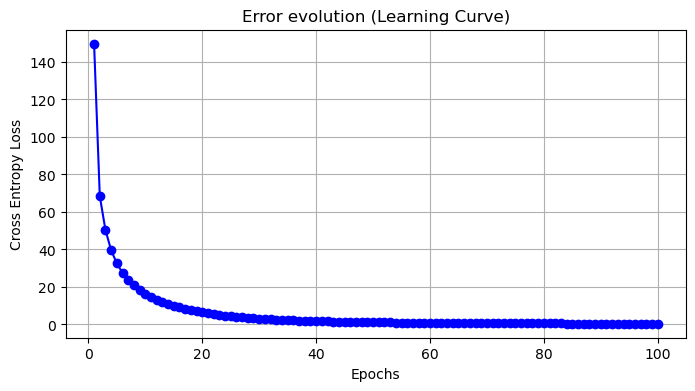

In [13]:
plot_learning_curve(loss, ylabel='Cross Entropy Loss')

In [14]:
probs = model.predict(X_test)      
preds=np.argmax(probs,axis=1)

In [15]:
#for  pred, yi in zip( preds, test_labels):
#    print(f"true: {int(yi)}  prediction: {pred} ")

accuracy = np.mean(preds == test_labels)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 98.31%
